<a href="https://colab.research.google.com/github/CHANGE1096ME/-UBER-RIDE-CANCELLATION-ANALYSIS-/blob/main/UBER_RIDE_CANCELLATION_ANALYSIS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 UBER RIDE CANCELLATION ANALYSIS - NumPy · Pandas · Matplotlib · Seaborn

---



Case Study: Solving the Uber Ride Cancellation Crisis


---

## 🎯 WORKFLOW OF PROJECT

By the end of this Project  we will be able to:

| # | Skill | Tool |
|---|-------|------|
| 1 | Import the four core data science libraries | All |
| 2 | Create arrays and run fast calculations | **NumPy** |
| 3 | Load, explore, clean, and filter a dataset | **Pandas** |
| 4 | Create new columns from existing data | **Pandas** |
| 5 | Draw bar charts, pie charts, and line charts | **Matplotlib** |
| 6 | Draw countplots, heatmaps, and boxplots | **Seaborn** |
| 7 | Summarise data with GroupBy (Python Pivot Tables) | **Pandas** |
| 8 | Translate findings into business recommendations | **All** |

---

## 🗺️ Project Roadmap

```
MODULE 0  →  The Business Problem        
MODULE 1  →  Importing Libraries         
MODULE 2  →  NumPy Basics              
MODULE 3  →  Pandas: Load & Explore      
MODULE 4  →  Feature Engineering         
MODULE 5  →  Matplotlib Charts           
MODULE 6  →  Seaborn Charts              
MODULE 7  →  GroupBy & Pivot Tables      
MODULE 8  →  Root Cause & Recommendations
```

## 📦 The Dataset

**6,745 Uber ride records — July to December 2016 — between a city and its airport.**

| Column | What it means |
|--------|---------------|
| `Request id` | Unique ride ID |
| `Pickup point` | `'City'` or `'Airport'` |
| `Driver id` | Driver assigned |
| `Status` | `Trip Completed` / `Cancelled` / `No Cars Available` |
| `Request timestamp` | When the rider booked |
| `Drop timestamp` | When the rider was dropped off (blank if cancelled) |



---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🚗 STEP 0 — The Business Problem</h2>

</div>

## The Story

> *You are a Data Scientist at Uber. Your Product Manager walks in on Monday morning and says:*
>
> **"Riders are furious. They book a cab, but either the driver cancels or the app says 'No Cars Available' — especially for airport trips. We are losing thousands of rides every week.**
>
> **Your job: find out WHY and tell us what to do about it."**

---

### 🤔 Think Before You Code

Before opening any data, a good analyst asks clarifying questions first.

| ❓ Question | 🎯 Why it matters |
|------------|------------------|
| Is this happening at specific times of day? | Could be a rush-hour problem |
| Is it City→Airport, Airport→City, or both? | Different routes may need different fixes |
| Is the failure 'Cancelled' or 'No Cars Available'? | These are completely different root causes |
| Has anything changed recently (incentives, app updates)? | Could point to a single trigger |

> 💡 **The data we have can answer all of these. That's exactly what we'll do today.**




##📦 STEP 1 — Importing Libraries

*   List item
*   List item







In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🔢 STEP 2 — NumPy: The Fast Calculator</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Process a million numbers in one shot</p>
</div>

## What is NumPy?

**NumPy = Numerical Python.** It is the foundation everything else is built on. Think of it as a calculator that handles a million numbers at once.

### Python List vs NumPy Array

```
Python list — numbers scattered in memory → SLOW
[ box1 ][ box2 ][ box3 ][ box4 ][ box5 ]

NumPy array — numbers packed side by side → FAST (50–300×)
| 1 | 2 | 3 | 4 | 5 |  ← like a ruler
```

### NumPy → Excel mapping

| NumPy | Excel |
|-------|-------|
| `np.mean(arr)` | `=AVERAGE()` |
| `np.max(arr)` | `=MAX()` |
| `np.min(arr)` | `=MIN()` |
| `np.sum(arr)` | `=SUM()` |
| `np.std(arr)` | `=STDEV()` |


In [ ]:
# NUMPY EXAMPLE 1: Ride Duration Statistics
# We have 10 sample ride durations (minutes). Let's analyse them.

ride_durations = np.array([12, 25, 8, 45, 30, 18, 22, 15, 37, 28])


print("Ride durations (min):", ride_durations)
print()
print("Average :", np.mean(ride_durations), "min")
print("Longest :", np.max(ride_durations),  "min")
print("Shortest:", np.min(ride_durations),  "min")
print("Median  :", np.median(ride_durations), "min")
print("Std Dev :", round(np.std(ride_durations), 2), "min")

Ride durations (min): [12 25  8 45 30 18 22 15 37 28]

Average : 24.0 min
Longest : 45 min
Shortest: 8 min
Median  : 23.5 min
Std Dev : 10.88 min


In [ ]:
# NUMPY EXAMPLE 2: Surge Pricing
# Uber charges 1.5× during peak hours.
# Multiply ALL fares at once !

base_fares  = np.array([150, 200, 120, 300, 250])   # fares in Rupees
surge_fares = base_fares * 1.5                       # apply to ALL at once

print("Base fares  (₹):", base_fares)
print("Surge fares (₹):", surge_fares)
print()
print("NumPy multiplied all 5 values in one line.")
print("At 1 million rows it would still be one line — and take milliseconds!")

Base fares  (₹): [150 200 120 300 250]
Surge fares (₹): [225. 300. 180. 450. 375.]

NumPy multiplied all 5 values in one line.
At 1 million rows it would still be one line — and take milliseconds!


##🗂️ STEP 3 — Pandas: Load, explore, clean, and filter your data






In [ ]:
# PANDAS STEP 1: Build a tiny DataFrame from scratch
# Before loading real data, let's build one by hand — like a 5-row Excel table.

sample_data = {
    'RideID':   [101, 102, 103, 104, 105],
    'Pickup':   ['Airport', 'City', 'Airport', 'City', 'Airport'],
    'Duration': [35, 22, 48, 15, 60],
    'Status':   ['Completed', 'Cancelled', 'Completed', 'Completed', 'No Cars']
}
# Each key   = column name
# Each list  = the values in that column

sample_df = pd.DataFrame(sample_data)
sample_df

,RideID,Pickup,Duration,Status
0,101,Airport,35,Completed
1,102,City,22,Cancelled
2,103,Airport,48,Completed
3,104,City,15,Completed
4,105,Airport,60,No Cars


In [ ]:
df=pd.read_csv("/content/uber-data.csv")
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


In [ ]:
df.shape

(6745, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [ ]:
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'])
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
 6   RequestHour        6745 non-null   int32         
 7   TimeSlot           6745 non-null   object        
 8   Cab Availability   6745 non-null   object        
dtypes: datetime64[ns](2), float64(1), int32(1), int64(1), object(4)
memory usage: 448.0+ KB


In [ ]:
df.isnull().sum()#Missing drop time = ride that never completed = a signal in itself.

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request timestamp,0
Drop timestamp,3914
RequestHour,0
TimeSlot,0
Cab Availability,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
cancelled_rides = df[df['Status'] == 'Cancelled']
airport_rides   = df[df['Pickup point'] == 'Airport']
print(f"  Cancelled rides  : {len(cancelled_rides):,}")
print(f"  Airport pickups  : {len(airport_rides):,}")
airport_cancelled = df[(df['Pickup point'] == 'Airport') & (df['Status'] == 'Cancelled')]
city_cancelled    = df[(df['Pickup point'] == 'City')    & (df['Status'] == 'Cancelled')]
print(f"  Airport cancels  : {len(airport_cancelled):,}")
print(f"  City cancels     : {len(city_cancelled):,}")
ratio = len(city_cancelled) / max(len(airport_cancelled), 1)
print(f" City cancellations are {ratio:.1f}x higher than Airport cancellations!")



  Cancelled rides  : 1,264
  Airport pickups  : 3,238
  Airport cancels  : 198
  City cancels     : 1,066
 City cancellations are 5.4x higher than Airport cancellations!


---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🔧 STEP 4 — Feature Engineering</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Creating new, useful columns from existing data</p>
</div>

## What is Feature Engineering?

Raw data often doesn't have **everything** we need for analysis. We **create** new columns from existing ones.

> **Analogy:** You have a student's date of birth. From ONE column, you can create:
> - **Age** (right now)
> - **Age group** (Child / Teen / Adult / Senior)
> - **Birth month** (seasonal pattern?)
>
> That's Feature Engineering!

## What We'll Create

| New Column | Source Column | Purpose |
|------------|--------------|---------|
| `RequestHour` | `Request timestamp` | Find rush-hour patterns |
| `TimeSlot` | `RequestHour` | Group hours into named periods |
| `Cab Availability` | `Status` | Simple Available/Not Available flag |
| `Duration_mins` | Both timestamps | Ride duration in minutes |


In [ ]:
df['RequestHour'] = df['Request timestamp'].dt.hour #new column of hours from timestamp

In [ ]:
df.head(1)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11


In [ ]:
def assign_timeslot(hour):
    if   hour <= 4:  return 'Dawn'
    elif hour <= 9:  return 'Early Morning'
    elif hour <= 16: return 'Noon'
    elif hour <= 21: return 'Late Evening'
    else:            return 'Night'

In [ ]:
df['TimeSlot'] = df['RequestHour'].apply(assign_timeslot)# new column using request hours
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour,TimeSlot
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11,Noon
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17,Late Evening
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9,Early Morning
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21,Late Evening
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8,Early Morning


In [ ]:
df['Status'].unique()

array(['Trip Completed', 'Cancelled', 'No Cars Available'], dtype=object)

In [ ]:
df['Cab Availability'] = df['Status'].apply(
    lambda x: 'Available' if x == 'Trip Completed' else 'Not Available'
)

In [ ]:
df['Cab Availability'].value_counts()

,count
Cab Availability,
Not Available,3914
Available,2831


In [ ]:
df['Cab Availability'].value_counts(normalize= True)

,proportion
Cab Availability,
Not Available,0.580282
Available,0.419718


In [ ]:
# Drop timestamp − Request timestamp = ride duration
# Only possible for COMPLETED rides (others have no drop time)

completed = df[df['Status'] == 'Trip Completed'].copy()
completed['Duration_mins'] = (
    (completed['Drop timestamp'] - completed['Request timestamp'])
    .dt.total_seconds() / 60   # seconds → minutes
)

print(" Ride Duration Statistics (completed rides only):")
print(completed['Duration_mins'].describe().round(2))
print()
median_dur = completed['Duration_mins'].median()
print(f" The median ride is {median_dur:.0f} minutes — a big time commitment for drivers.")
print("   No wonder they prefer shorter city rides over airport trips!")

⏱️  Ride Duration Statistics (completed rides only):
count      2831.00
mean       -645.97
std       14827.86
min     -213086.08
25%          41.00
50%          52.08
75%          64.00
max       41835.00
Name: Duration_mins, dtype: float64

💡 The median ride is 52 minutes — a big time commitment for drivers.
   No wonder they prefer shorter city rides over airport trips!


In [ ]:
df[['Request timestamp', 'Pickup point', 'Status',
    'RequestHour', 'TimeSlot', 'Cab Availability']].head(8)

,Request timestamp,Pickup point,Status,RequestHour,TimeSlot,Cab Availability
0,2016-11-07 11:51:00,Airport,Trip Completed,11,Noon,Available
1,2016-11-07 17:57:00,Airport,Trip Completed,17,Late Evening,Available
2,2016-12-07 09:17:00,City,Trip Completed,9,Early Morning,Available
3,2016-12-07 21:08:00,Airport,Trip Completed,21,Late Evening,Available
4,2016-07-13 08:33:16,City,Trip Completed,8,Early Morning,Available
5,2016-07-13 21:57:28,Airport,Trip Completed,21,Late Evening,Available
6,2016-07-14 06:15:32,Airport,Trip Completed,6,Early Morning,Available
7,2016-07-15 05:11:52,Airport,Trip Completed,5,Early Morning,Available


##📊 STEP 5 — Matplotlib: Drawing Charts with Code


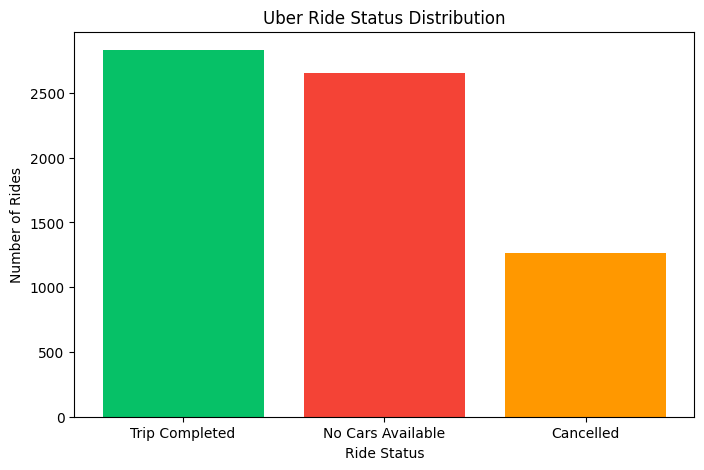

 KEY INSIGHT: Nearly 3 in 5 ride requests go unfulfilled — structural problem!


In [ ]:
# ============================================================
# CHART 1: Bar Chart — Ride Status Distribution
# ============================================================
# QUESTION: "What percentage of rides are actually completing?"

status_counts = df['Status'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values,
        color=['#06C167', '#F44336', '#FF9800'])
plt.title('Uber Ride Status Distribution')
plt.xlabel('Ride Status')
plt.ylabel('Number of Rides')
plt.show()
print(" KEY INSIGHT: Nearly 3 in 5 ride requests go unfulfilled — structural problem!")

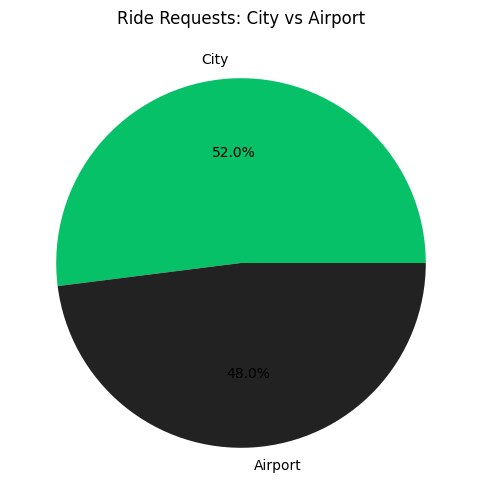

💡 Almost equal split — both routes have problems.


In [ ]:
#CHART 2: Pie Chart — City vs Airport Pickup Split
# ============================================================
# QUESTION: "Is the problem equally bad at both locations?"
pickup_counts = df['Pickup point'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(pickup_counts.values,
        labels=pickup_counts.index,
        autopct='%1.1f%%',
        colors=['#06C167', '#222222'])
plt.title('Ride Requests: City vs Airport')
plt.show()

print("💡 Almost equal split — both routes have problems.")

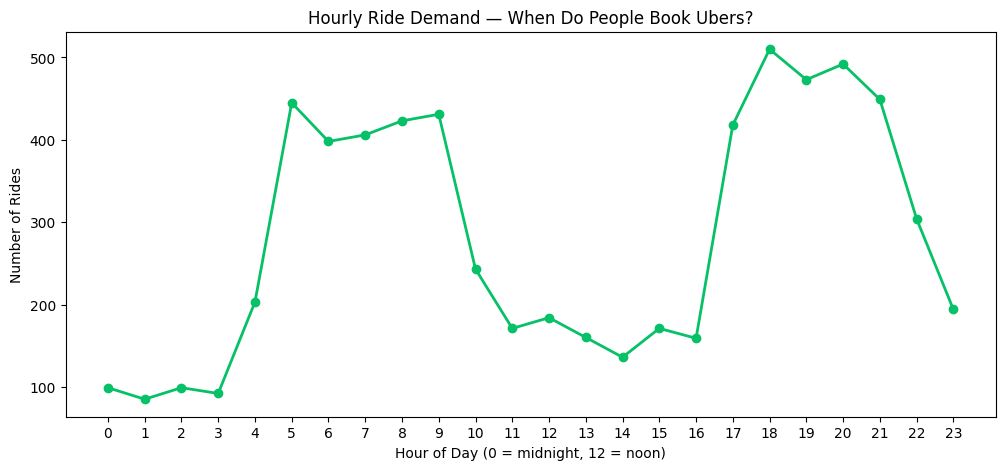

 KEY INSIGHT: Two clear demand peaks — 5–9 AM and 5–9 PM.
   These are EXACTLY the hours where supply is failing.


In [ ]:
# CHART 3: Line Chart — Hourly Demand Trend
# ============================================================
# QUESTION: "When do people book Ubers? When is demand highest?"
hourly_demand = df.groupby('RequestHour').size()
# groupby('RequestHour') groups rows by hour
# .size() counts the rows in each group

plt.figure(figsize=(12, 5))
plt.plot(hourly_demand.index, hourly_demand.values,
         color='#06C167', linewidth=2, marker='o')
plt.title('Hourly Ride Demand — When Do People Book Ubers?')
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.show()
print(" KEY INSIGHT: Two clear demand peaks — 5–9 AM and 5–9 PM.")
print("   These are EXACTLY the hours where supply is failing.")

---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🎨 STEP 6 — Seaborn: Matplotlib's Smarter, Prettier Cousin</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Statistical visualisations with dramatically less code</p>
</div>

## Seaborn vs Matplotlib

> **Analogy:** If Matplotlib is a manual car — full control, many steps — Seaborn is an automatic. Fewer steps, same destination, and it looks better out of the box.

Seaborn is built **on top of** Matplotlib and adds:
- **Automatic counting** (`sns.countplot` — no pre-processing needed!)
- **Statistical extras** (confidence intervals, distribution curves)
- **Better default aesthetics**

| Chart | Command | When to Use |
|-------|---------|-------------|
| Count bars | `sns.countplot()` | Count categories automatically from raw data |
| Heatmap | `sns.heatmap()` | Patterns across two dimensions |
| Boxplot | `sns.boxplot()` | Distribution and spread of numbers |
| Histogram | `sns.histplot()` | Frequency distribution |


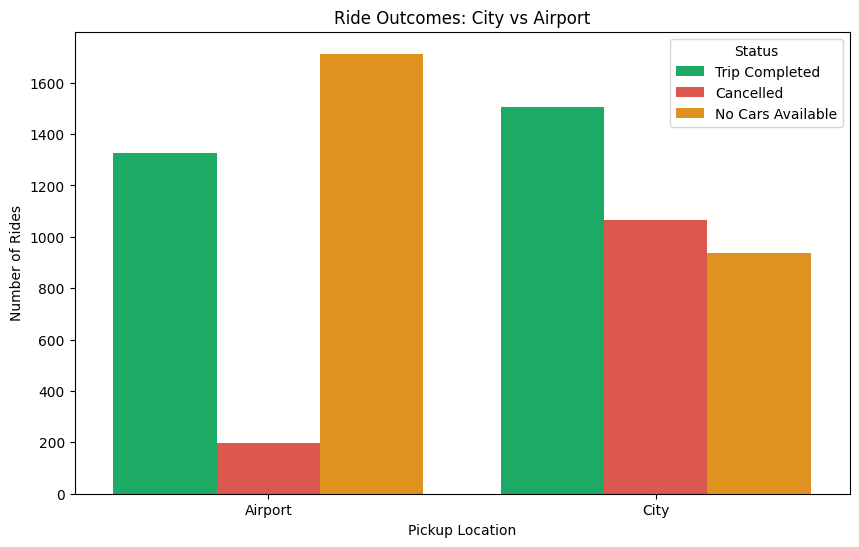

   City    → HIGH Cancellations  (drivers don't want airport trips)
   Airport → HIGH No Cars Available  (no cabs are near the airport)
   Two DIFFERENT problems needing two DIFFERENT solutions!


In [ ]:
# CHART 4: Seaborn Countplot — Status by Pickup Point
# ============================================================
# QUESTION: "Which location has most cancellations? Most 'No Cars'?"
# KEY: sns.countplot counts AUTOMATICALLY — no groupby needed!
plt.figure(figsize=(10, 6))
sns.countplot(data=df,
              x='Pickup point',
              hue='Status',
              palette=['#06C167', '#F44336', '#FF9800'])
plt.title('Ride Outcomes: City vs Airport')
plt.xlabel('Pickup Location')
plt.ylabel('Number of Rides')
plt.show()

print("   City    → HIGH Cancellations  (drivers don't want airport trips)")
print("   Airport → HIGH No Cars Available  (no cabs are near the airport)")
print("   Two DIFFERENT problems needing two DIFFERENT solutions!")

/tmp/ipykernel_653/2149336111.py:27: UserWarning: Glyph 128748 (\N{AIRPLANE ARRIVING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128748 (\N{AIRPLANE ARRIVING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


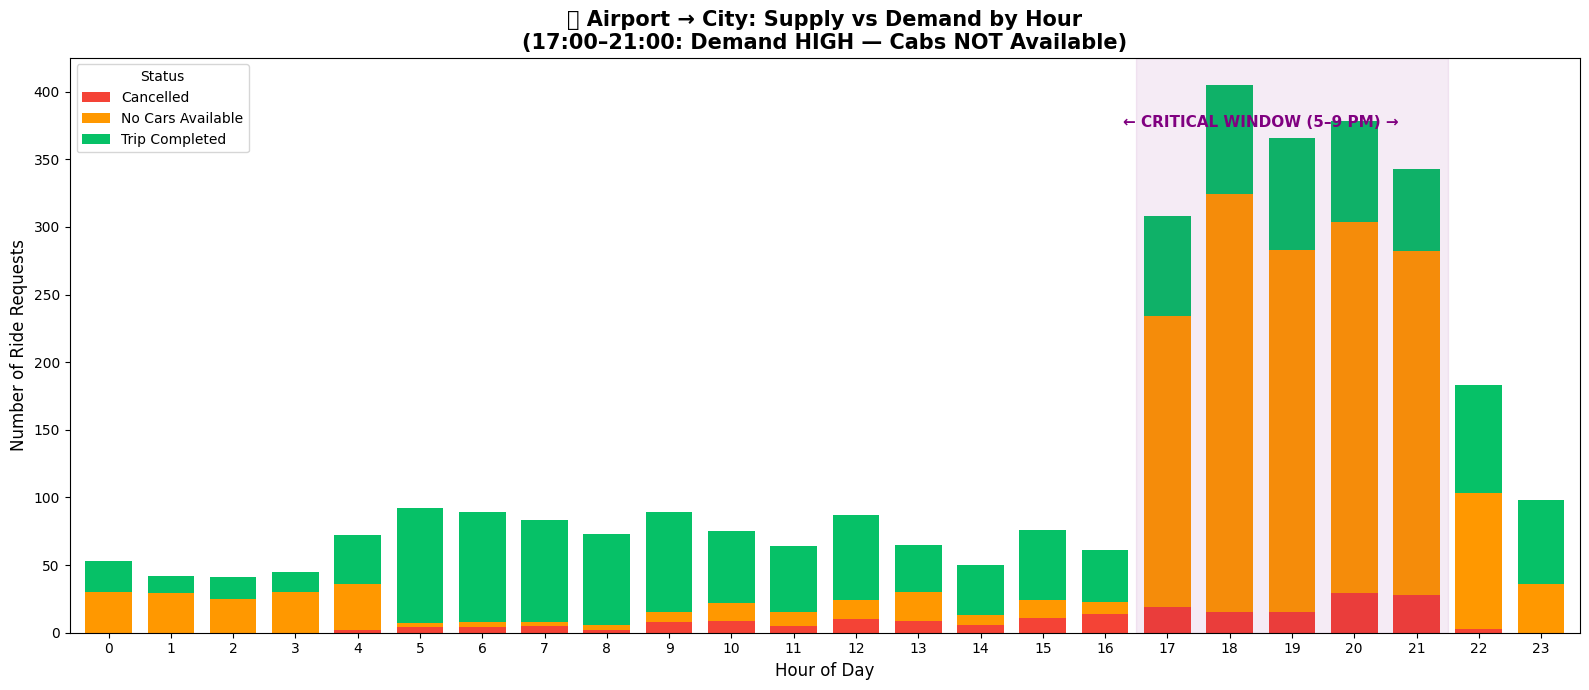

💡 ROOT CAUSE: Cabs dropped riders at Airport in the morning and never returned.
   By evening, there are zero cabs near the Airport. Supply gap is structural.


In [ ]:
# ============================================================
# CHART 5: Stacked Bar — Airport → City Demand-Supply Gap
# ============================================================
# QUESTION: "When is the Airport→City gap worst?"

airport_hourly = df[df['Pickup point'] == 'Airport'].groupby(
    ['RequestHour', 'Status']
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
airport_hourly.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'],
    ax=ax, width=0.75
)
ax.axvspan(16.5, 21.5, alpha=0.08, color='purple')
ax.text(18.5, ax.get_ylim()[1] * 0.88, '← CRITICAL WINDOW (5–9 PM) →',
        ha='center', color='purple', fontweight='bold', fontsize=11)

ax.set_title('🛬 Airport → City: Supply vs Demand by Hour\n'
             '(17:00–21:00: Demand HIGH — Cabs NOT Available)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Ride Requests', fontsize=12)
ax.legend(title='Status', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("💡 ROOT CAUSE: Cabs dropped riders at Airport in the morning and never returned.")
print("   By evening, there are zero cabs near the Airport. Supply gap is structural.")

/tmp/ipykernel_653/2051155136.py:26: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


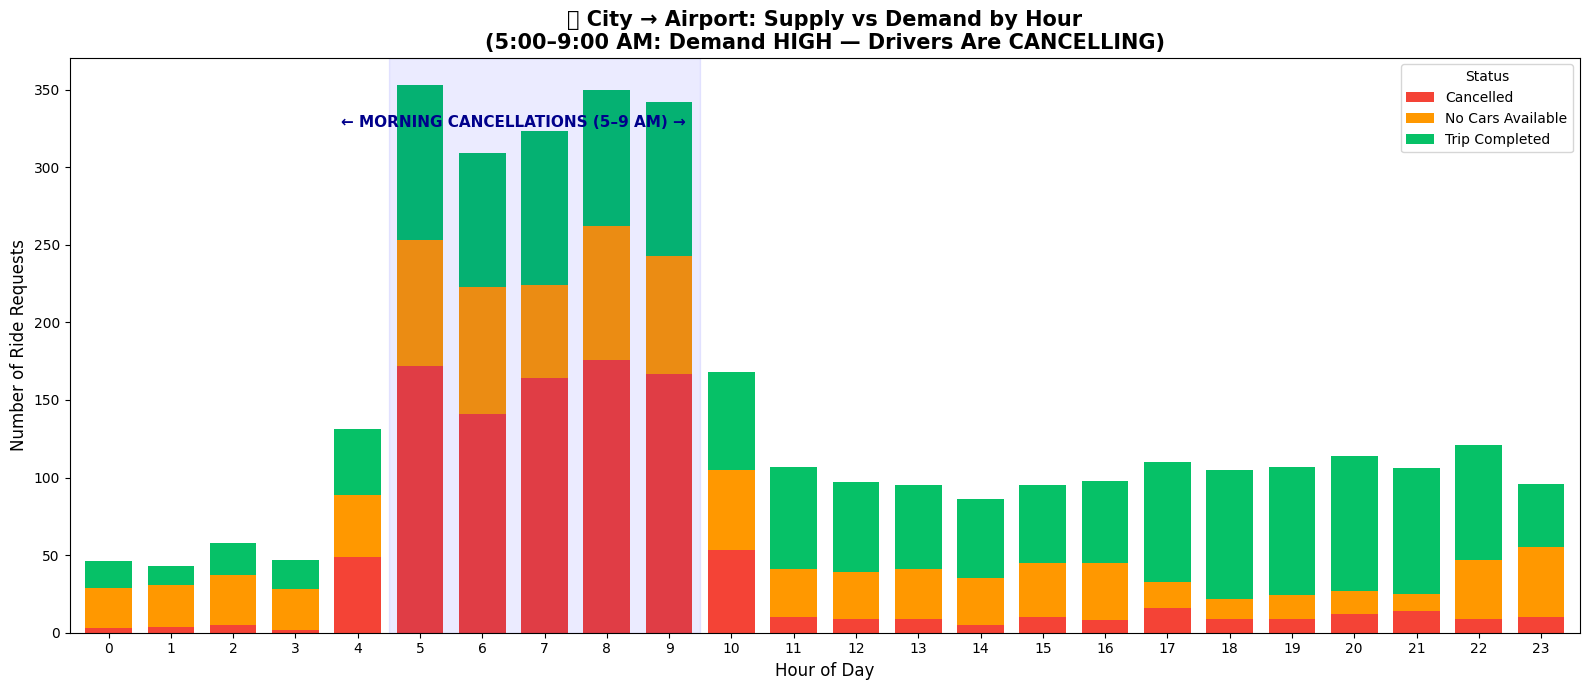

💡 ROOT CAUSE: Drivers cancel because the economics don't work for them.
   Long pickup distance + long airport wait + no guaranteed return = not worth it.


In [ ]:
# ============================================================
# CHART 6: Stacked Bar — City → Airport Demand-Supply Gap
# ============================================================

city_hourly = df[df['Pickup point'] == 'City'].groupby(
    ['RequestHour', 'Status']
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
city_hourly.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'],
    ax=ax, width=0.75
)
ax.axvspan(4.5, 9.5, alpha=0.08, color='blue')
ax.text(6.5, ax.get_ylim()[1] * 0.88, '← MORNING CANCELLATIONS (5–9 AM) →',
        ha='center', color='darkblue', fontweight='bold', fontsize=11)

ax.set_title('🏙️ City → Airport: Supply vs Demand by Hour\n'
             '(5:00–9:00 AM: Demand HIGH — Drivers Are CANCELLING)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Ride Requests', fontsize=12)
ax.legend(title='Status', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("💡 ROOT CAUSE: Drivers cancel because the economics don't work for them.")
print("   Long pickup distance + long airport wait + no guaranteed return = not worth it.")

/tmp/ipykernel_653/2551899119.py:21: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


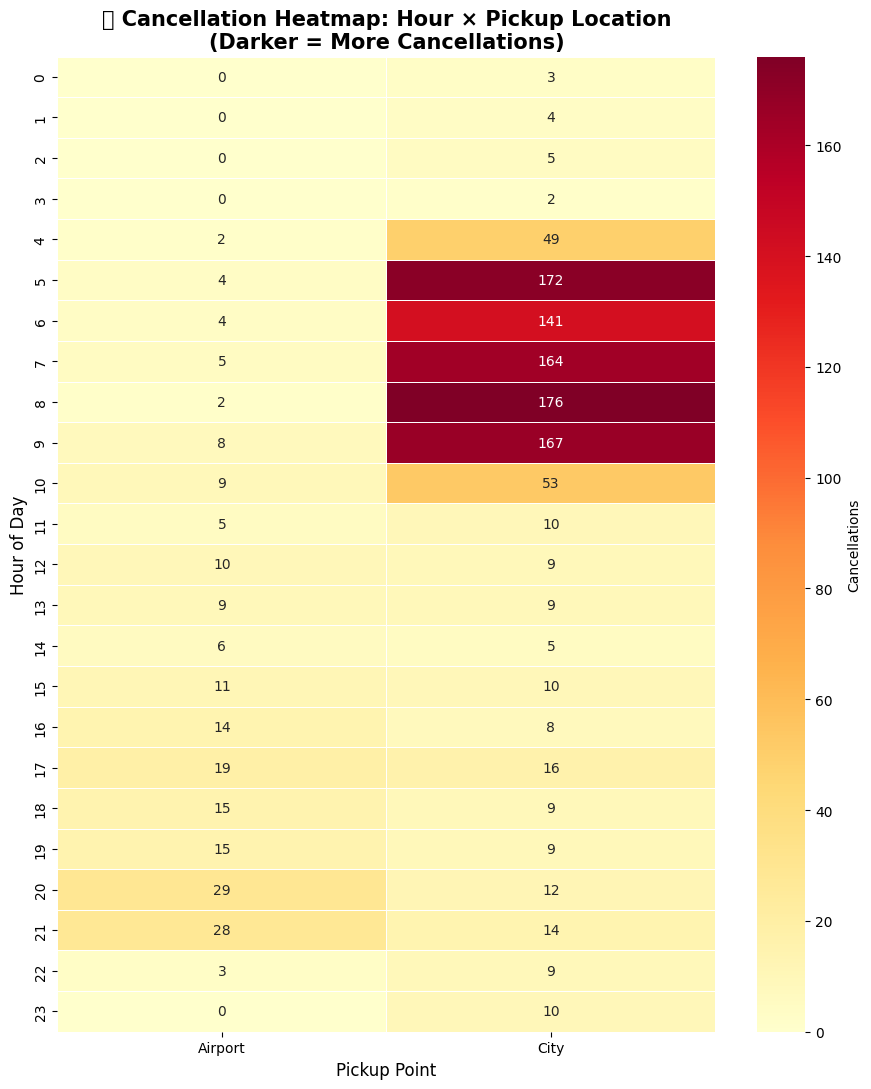

💡 KEY INSIGHT: Hours 5–9 in the City column are dark red.
   Morning rush = peak cancellation window for City→Airport rides.


In [ ]:
#CHART 7: Heatmap — Cancellations by Hour & Pickup Point
cancelled_df = df[df['Status'] == 'Cancelled']
heatmap_data = cancelled_df.groupby(
    ['RequestHour', 'Pickup point']
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='d',           # show numbers inside cells, as integers
    cmap='YlOrRd',                  # Yellow → Orange → Red
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Cancellations'}
)
ax.set_title('🔥 Cancellation Heatmap: Hour × Pickup Location\n'
             '(Darker = More Cancellations)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Pickup Point', fontsize=12)
ax.set_ylabel('Hour of Day', fontsize=12)
plt.tight_layout()
plt.show()

print("💡 KEY INSIGHT: Hours 5–9 in the City column are dark red.")
print("   Morning rush = peak cancellation window for City→Airport rides.")

/tmp/ipykernel_653/3636656435.py:26: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


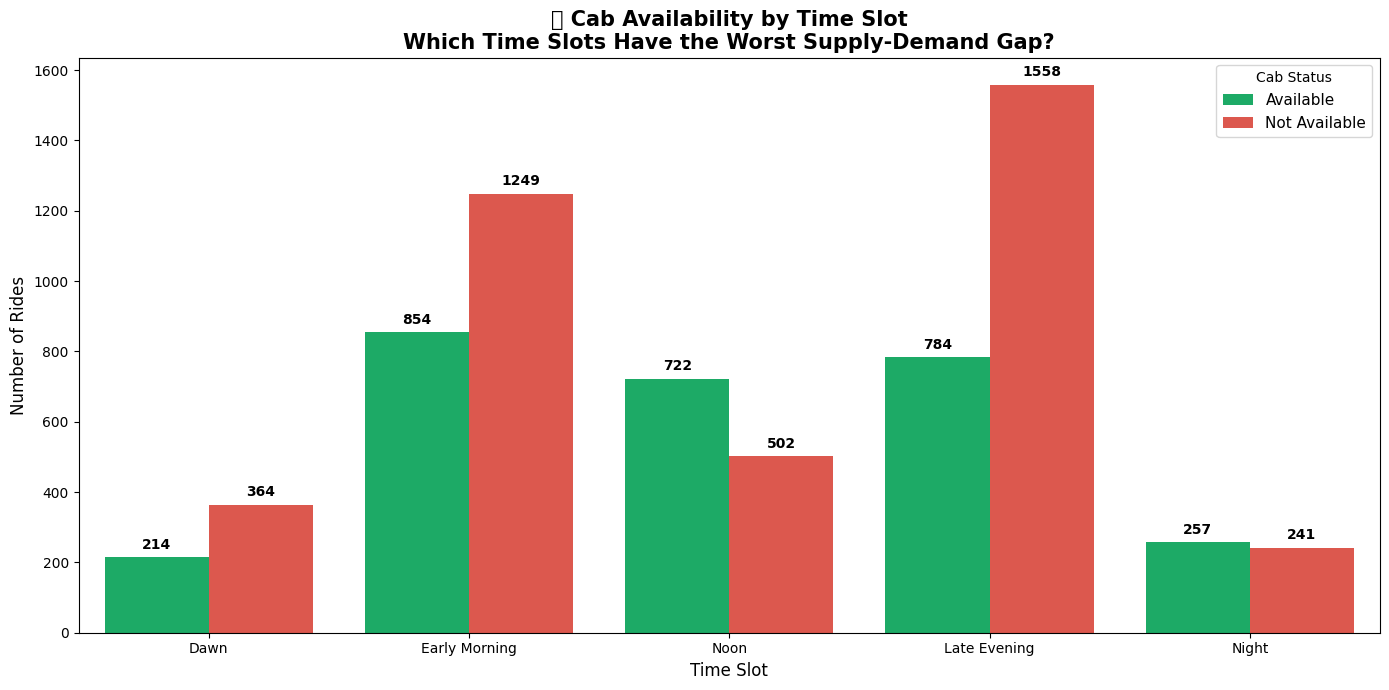

💡 KEY INSIGHT: 'Early Morning' and 'Late Evening' have the WORST gaps.
   These are the exact windows Uber needs to target with new incentives.


In [ ]:
# ============================================================
# CHART 9: Countplot — Cab Availability by Time Slot
# ============================================================
# QUESTION: "Which time slot has the worst gap?"

timeslot_order = ['Dawn', 'Early Morning', 'Noon', 'Late Evening', 'Night']

fig, ax = plt.subplots(figsize=(14, 7))
sns.countplot(
    data=df,
    x='TimeSlot',
    hue='Cab Availability',
    palette=['#06C167', '#F44336'],
    order=timeslot_order,
    ax=ax
)
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10, fontweight='bold')

ax.set_title('🕐 Cab Availability by Time Slot\n'
             'Which Time Slots Have the Worst Supply-Demand Gap?',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Time Slot', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.legend(title='Cab Status', fontsize=11)
plt.tight_layout()
plt.show()

print("💡 KEY INSIGHT: 'Early Morning' and 'Late Evening' have the WORST gaps.")
print("   These are the exact windows Uber needs to target with new incentives.")

##📊 STEP 7 — GroupBy & Aggregation: Pivot Tables in Python

In [ ]:
# ============================================================
# GROUPBY 1: Rides per Pickup Point
# ============================================================

rides_by_pickup = df.groupby('Pickup point').size()
print("📊 Rides per Pickup Point:")
print(rides_by_pickup)

print()
print("📊 Rides by Pickup Point × Status (Pivot Table):")
rides_pivot = df.groupby(['Pickup point', 'Status']).size().unstack(fill_value=0)
#                                                    ↑
#                .unstack() turns Status into column headers — just like an Excel pivot!
print(rides_pivot)

📊 Rides per Pickup Point:
Pickup point
Airport    3238
City       3507
dtype: int64

📊 Rides by Pickup Point × Status (Pivot Table):
Status        Cancelled  No Cars Available  Trip Completed
Pickup point                                              
Airport             198               1713            1327
City               1066                937            1504


In [ ]:
# ============================================================
# GROUPBY 2: Cancellation Rate per Pickup Point
# ============================================================

print("📉 Failure Rates by Pickup Point:")
print()
for pickup in ['City', 'Airport']:
    subset       = df[df['Pickup point'] == pickup]
    cancel_count = (subset['Status'] == 'Cancelled').sum()
    nocars_count = (subset['Status'] == 'No Cars Available').sum()
    total        = len(subset)

    print(f"    {pickup}:  (n = {total:,})")
    print(f"     Cancellation rate    : {cancel_count/total*100:.1f}%")
    print(f"     No Cars Available    : {nocars_count/total*100:.1f}%")
    print(f"     Completion rate ✅   : {(1 - (cancel_count+nocars_count)/total)*100:.1f}%")
    print()

📉 Failure Rates by Pickup Point:

    City:  (n = 3,507)
     Cancellation rate    : 30.4%
     No Cars Available    : 26.7%
     Completion rate ✅   : 42.9%

    Airport:  (n = 3,238)
     Cancellation rate    : 6.1%
     No Cars Available    : 52.9%
     Completion rate ✅   : 41.0%



/tmp/ipykernel_653/3081841020.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


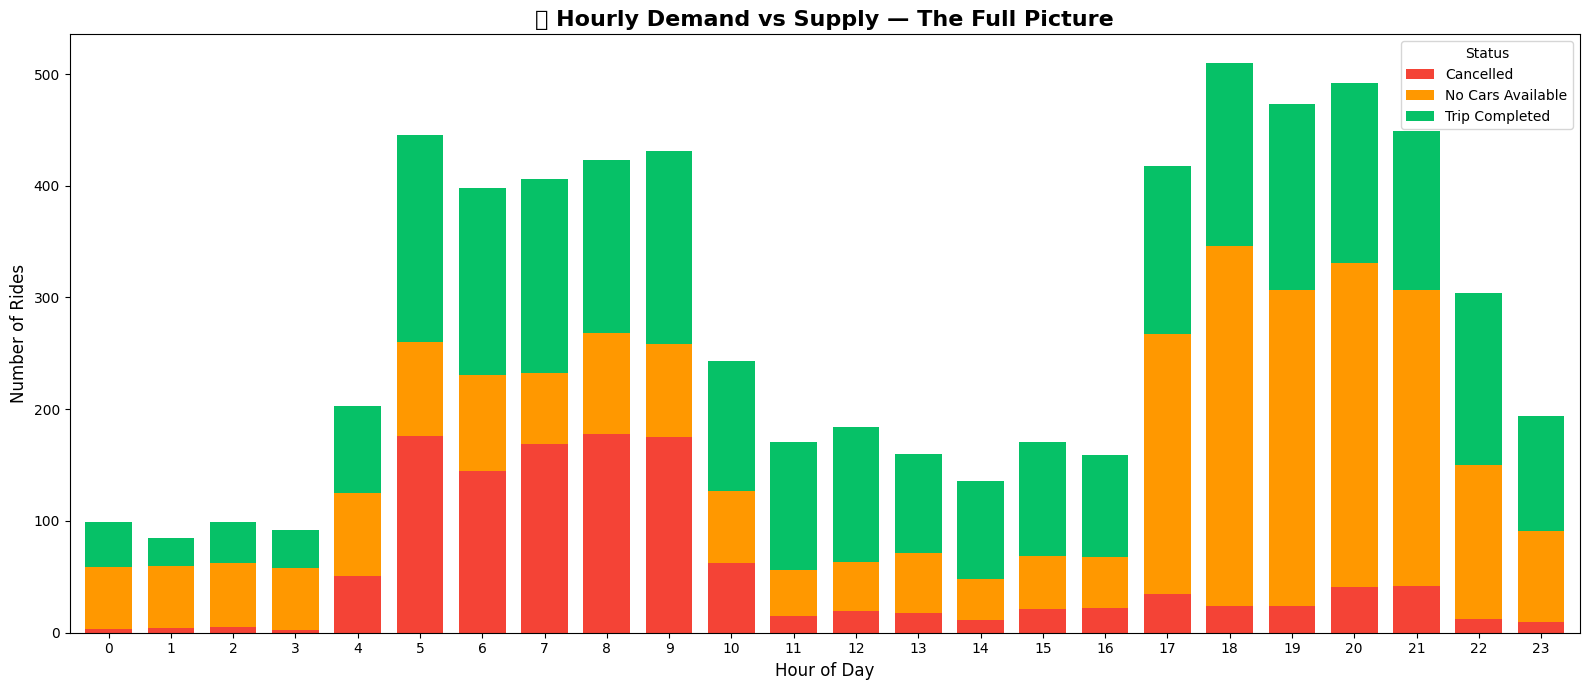

In [ ]:
# ============================================================
# GROUPBY 3: Hourly Supply-Demand Gap — Full Picture
# ============================================================

hourly_status = df.groupby(['RequestHour', 'Status']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
hourly_status.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'],
    ax=ax, width=0.75
)
ax.set_title('📊 Hourly Demand vs Supply — The Full Picture', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.legend(title='Status', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

<div style="background: linear-gradient(90deg, #000000, #1c1c1c); padding: 20px 28px; border-radius: 10px; border-left: 6px solid #06C167;">
<h2 style="color: #06C167; margin: 0;">🔬 STEP 8 — Root Cause Analysis & Business Recommendations</h2>
<p style="color: #aaa; margin: 6px 0 0 0;">Putting it all together like a detective presenting findings</p>
</div>

## 📢 What the Data Told Us

| Finding | Chart Evidence | Root Cause |
|---------|---------------|------------|
| **58% of all ride requests FAIL** | Status bar chart: 3,914 failures / 6,745 total | Structural supply-demand mismatch |
| **Airport→City gap peaks 5–9 PM** | Airport stacked bar: 'No Cars' dominates evenings | Cabs dropped at Airport in morning, never returned |
| **City→Airport gap peaks 5–9 AM** | City stacked bar: 'Cancelled' dominates mornings | Driver economics don't favour airport trips |
| **Early Morning & Late Evening worst** | Countplot by time slot | Rush-hour spikes exceed fixed supply of ~300 drivers |

## ✅ Recommended Solutions

| # | Recommendation | What to Do | Expected Impact |
|---|----------------|-----------|----------------|
| 1 | **Airport Waiting Bonus** | Pay drivers ₹50 for every 15 min they wait at airport after drop | Keeps drivers near airport → reduces 'No Cars' evening |
| 2 | **Night Shift Premium** | 1.5× fare for all trips between 10 PM and 6 AM | Incentivises drivers for gap hours |
| 3 | **Pre-position Fleet** | Place 20% of city fleet near airport by 4:30 PM based on demand forecast | Closes the Airport→City evening gap proactively |
| 4 | **Guaranteed Return Fare** | Guarantee City→Airport→City as one combined booking | Removes economic disincentive → reduces cancellations |
| 5 | **Wider Airport Search** | Expand pickup search radius from 3 km to 10 km | More drivers considered → fewer 'No Cars' messages |
